Daily Challenge:

Your Task

    Data Exploration: Load and visualize the data.
        Use pandas to load the dataset and examine the first few rows.
        Create a scatter plot to visualize the data points for students who were admitted versus those who were not based on their exam scores.

    Applying Logistic Regression with scikit-learn:
        Implement logistic regression using the LogisticRegression function from scikit-learn to find the best parameters for your model.
        Train the logistic regression model on your dataset.

    Making Predictions:
        Use the trained logistic regression model to make predictions on your dataset.
        Calculate the accuracy of your model.

    Model Evaluation:
        Interpret the result of logistic regression and the accuracy of your model.


In [16]:
# Daily Challenge
# "    Data Exploration: Load and visualize the data.
        # Use pandas to load the dataset and examine the first few rows."

import pandas as pd
import matplotlib.pyplot as plt
# Load the dataset
df = pd.read_csv('ex2data1.txt', header=None)
df.head()

,0,1,2
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


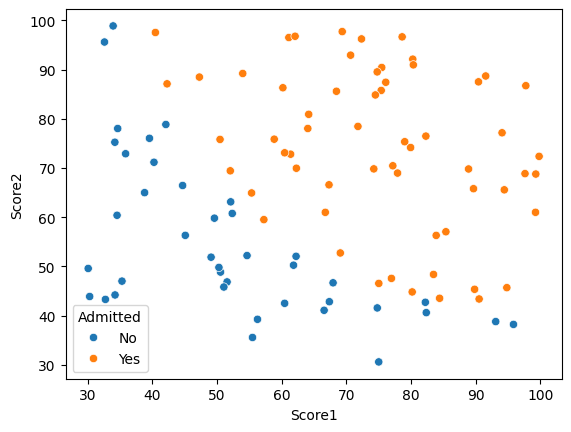

In [19]:
# Based on my understanding that this is a dataset of student admissions based on exam scores, columns 0 and 1 are exam scores and column 2 is an admission binary. Let's assign headers:
df.columns = ['Score1', 'Score2', 'Admitted']

# "Create a scatter plot to visualize the data points for students who were admitted versus those who were not based on their exam scores."
df1=df.copy()
df1['Admitted'] = df1['Admitted'].map({1: 'Yes', 0: 'No'})

import seaborn as sns
sns.scatterplot(data = df1, x='Score1',y='Score2',hue='Admitted')
plt.show()

In [ ]:
# "Applying Logistic Regression with scikit-learn:
    # Implement logistic regression using the LogisticRegression function from scikit-learn to find the best parameters for your model.
    # Train the logistic regression model on your dataset."

from sklearn.model_selection import train_test_split

X = df.drop('Admitted', axis=1) # axis=1 (columns axis)
y = df['Admitted']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

from sklearn.linear_model import LogisticRegression
# 1. Create
model = LogisticRegression(random_state=42, max_iter=1000)

# 2. Train
model.fit(X_train, y_train)

In [29]:
#    "Making Predictions:
        # Use the trained logistic regression model to make predictions on your dataset.
        # Calculate the accuracy of your model."
# 3. Predict
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')

Accuracy: 0.95


    Model Evaluation:
        Interpret the result of logistic regression and the accuracy of your model.

The result of logistic regression here is the model that can predict admission based on two test scores. The accuracy score means the proportion of predicted outcomes that were correct: all true predictions (true positives + false positives) out of all prediction instances. In this case the accuracy is 95% which is pretty high. Although a high accuracy does not necessarily indicate a very useful model because if there is a case imbalance and there are very few positives a model with high accuracy still might not capture a lot of the positives, we can recall how the scatterplot shows the classes are pretty balanced. Therefore, in this case, high accuracy indicates the model is reliable. Looking at precision and recall could confirm this.